In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


In [2]:
data_files = [
    '../data/raw/yellow_tripdata_2025-06.parquet',
    '../data/raw/yellow_tripdata_2025-07.parquet',
    '../data/raw/yellow_tripdata_2025-08.parquet',
    '../data/raw/yellow_tripdata_2025-09.parquet',
    '../data/raw/yellow_tripdata_2025-10.parquet',
    '../data/raw/yellow_tripdata_2025-11.parquet',
]

print("Loading all data files...")
dfs = []

for file in data_files:
    if os.path.exists(file):
        print(f"  Loading {file.split('/')[-1]}...")
        df_temp = pd.read_parquet(file)
        dfs.append(df_temp)
        print(f"    ✅ Loaded {len(df_temp):,} records")
    else:
        print(f"  ⚠️  File not found: {file}")

# Combine all data
df = pd.concat(dfs, ignore_index=True)

print("\n" + "="*60)
print("DATA LOADING COMPLETE")
print("="*60)
print(f"Total records: {len(df):,}")
print(f"Date range: {df['tpep_pickup_datetime'].min()} to {df['tpep_pickup_datetime'].max()}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("="*60)


Loading all data files...
  Loading yellow_tripdata_2025-06.parquet...
    ✅ Loaded 4,322,960 records
  Loading yellow_tripdata_2025-07.parquet...
    ✅ Loaded 3,898,963 records
  Loading yellow_tripdata_2025-08.parquet...
    ✅ Loaded 3,574,091 records
  Loading yellow_tripdata_2025-09.parquet...
    ✅ Loaded 4,251,015 records
  Loading yellow_tripdata_2025-10.parquet...
    ✅ Loaded 4,428,699 records
  Loading yellow_tripdata_2025-11.parquet...
    ✅ Loaded 4,181,444 records

DATA LOADING COMPLETE
Total records: 24,657,172
Date range: 2008-12-31 23:04:21 to 2025-11-30 23:59:59
Memory usage: 4454.57 MB


In [3]:
def clean_data(df):
    """Remove invalid and outlier records"""
    print(f"\nCleaning data...")
    print(f"Original records: {len(df):,}")
    
    df = df.copy()
    
    # Remove invalid pickup zones
    df = df[df['PULocationID'].notna()]
    df = df[df['PULocationID'] > 0]
    print(f"After removing invalid zones: {len(df):,}")
    
    # Remove invalid trip distances
    df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 100)]
    print(f"After removing invalid distances: {len(df):,}")
    
    # Remove invalid fares
    df = df[(df['fare_amount'] > 0) & (df['fare_amount'] < 500)]
    print(f"After removing invalid fares: {len(df):,}")
    
    # Remove invalid passenger counts
    df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]
    print(f"After removing invalid passengers: {len(df):,}")
    
    # Remove trips with invalid duration
    df['trip_duration'] = (pd.to_datetime(df['tpep_dropoff_datetime']) - 
                           pd.to_datetime(df['tpep_pickup_datetime'])).dt.total_seconds() / 60
    df = df[(df['trip_duration'] >= 1) & (df['trip_duration'] <= 180)]
    print(f"After removing invalid durations: {len(df):,}")
    
    print(f"\n✅ Cleaning complete!")
    
    return df

df_clean = clean_data(df)

# Save cleaned data
df_clean.to_parquet('../data/processed/cleaned_trips_full.parquet', index=False)
print(f"✅ Cleaned data saved!")


Cleaning data...
Original records: 24,657,172
After removing invalid zones: 24,657,172
After removing invalid distances: 23,932,367
After removing invalid fares: 22,320,595
After removing invalid passengers: 17,676,157
After removing invalid durations: 17,250,575

✅ Cleaning complete!
✅ Cleaned data saved!


In [4]:
def aggregate_demand(df):
    """Create hourly demand counts per zone"""
    print("\nAggregating demand by zone and hour...")
    
    df = df.copy()
    df['pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df['date'] = df['pickup_datetime'].dt.date
    df['hour'] = df['pickup_datetime'].dt.hour
    
    demand = df.groupby(['date', 'hour', 'PULocationID']).agg({
        'VendorID': 'count',
        'trip_distance': 'mean',
        'fare_amount': 'mean'
    }).reset_index()
    
    demand.columns = ['date', 'hour', 'PULocationID', 'demand', 'avg_distance', 'avg_fare']
    
    print(f"✅ Aggregated to {len(demand):,} records")
    print(f"Date range: {demand['date'].min()} to {demand['date'].max()}")
    print(f"Unique zones: {demand['PULocationID'].nunique()}")
    
    return demand

demand_df = aggregate_demand(df_clean)
demand_df.to_parquet('../data/processed/demand_aggregated_full.parquet', index=False)
print("✅ Aggregated demand saved!")


Aggregating demand by zone and hour...
✅ Aggregated to 513,924 records
Date range: 2008-12-31 to 2025-11-30
Unique zones: 262
✅ Aggregated demand saved!


In [5]:
def create_features(demand_df):
    """Create features for machine learning"""
    print("\nCreating features for ML...")
    
    df = demand_df.copy()
    df['date'] = pd.to_datetime(df['date'])
    
    # Temporal features
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_month'] = df['date'].dt.day
    df['month'] = df['date'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    df['is_morning_rush'] = ((df['hour'] >= 7) & (df['hour'] <= 9)).astype(int)
    df['is_evening_rush'] = ((df['hour'] >= 17) & (df['hour'] <= 19)).astype(int)
    df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
    df['is_business_hours'] = ((df['hour'] >= 9) & (df['hour'] <= 17)).astype(int)
    
    print("✅ Created temporal features")
    
    # Sort for lag features
    df = df.sort_values(['PULocationID', 'date', 'hour']).reset_index(drop=True)
    
    print("Creating lag features (this may take a few minutes with more data)...")
    
    # Lag features
    df['demand_lag_1h'] = df.groupby('PULocationID')['demand'].shift(1)
    df['demand_lag_24h'] = df.groupby('PULocationID')['demand'].shift(24)
    df['demand_lag_168h'] = df.groupby('PULocationID')['demand'].shift(168)
    
    print("✅ Created lag features")
    
    # Rolling statistics
    print("Creating rolling statistics...")
    
    df['demand_rolling_mean_3h'] = df.groupby('PULocationID')['demand'].transform(
        lambda x: x.rolling(window=3, min_periods=1).mean().shift(1)
    )
    df['demand_rolling_max_6h'] = df.groupby('PULocationID')['demand'].transform(
        lambda x: x.rolling(window=6, min_periods=1).max().shift(1)
    )
    df['demand_rolling_std_6h'] = df.groupby('PULocationID')['demand'].transform(
        lambda x: x.rolling(window=6, min_periods=1).std().shift(1)
    )
    
    print("✅ Created rolling features")
    
    # Drop NaN rows
    original_len = len(df)
    df = df.dropna()
    print(f"Dropped {original_len - len(df):,} rows with missing values")
    
    print(f"\n✅ Feature engineering complete!")
    print(f"Final dataset: {len(df):,} records with {len(df.columns)} columns")
    
    return df

feature_df = create_features(demand_df)
feature_df.to_parquet('../data/processed/features_for_ml_full.parquet', index=False)
print("✅ Feature dataset saved!")



Creating features for ML...
✅ Created temporal features
Creating lag features (this may take a few minutes with more data)...
✅ Created lag features
Creating rolling statistics...
✅ Created rolling features
Dropped 39,641 rows with missing values

✅ Feature engineering complete!
Final dataset: 474,283 records with 20 columns
✅ Feature dataset saved!


In [6]:
feature_df = feature_df.sort_values(['date', 'hour']).reset_index(drop=True)

# 80-20 split
split_idx = int(len(feature_df) * 0.8)
train_df = feature_df.iloc[:split_idx]
test_df = feature_df.iloc[split_idx:]

print("\n" + "="*60)
print("TRAIN/TEST SPLIT")
print("="*60)
print(f"Training period: {train_df['date'].min()} to {train_df['date'].max()}")
print(f"Test period:     {test_df['date'].min()} to {test_df['date'].max()}")
print(f"\nTraining samples: {len(train_df):,}")
print(f"Test samples:     {len(test_df):,}")
print("="*60)

# Define features
feature_cols = [
    'hour', 'day_of_week', 'day_of_month', 'month', 'is_weekend',
    'is_morning_rush', 'is_evening_rush', 'is_night', 'is_business_hours',
    'demand_lag_1h', 'demand_lag_24h', 'demand_lag_168h',
    'demand_rolling_mean_3h', 'demand_rolling_max_6h', 'demand_rolling_std_6h',
    'avg_distance', 'avg_fare'
]

X_train = train_df[feature_cols]
y_train = train_df['demand']
X_test = test_df[feature_cols]
y_test = test_df['demand']

print(f"\n✅ Data prepared for training!")


TRAIN/TEST SPLIT
Training period: 2025-06-07 00:00:00 to 2025-10-30 00:00:00
Test period:     2025-10-30 00:00:00 to 2025-11-30 00:00:00

Training samples: 379,426
Test samples:     94,857

✅ Data prepared for training!


In [7]:
print("\n" + "="*60)
print("TRAINING IMPROVED XGBOOST MODEL")
print("="*60)

# Improved parameters for larger dataset
model = xgb.XGBRegressor(
    objective='reg:squarederror',
    max_depth=8,                    # Increased from 6 (more complex patterns)
    learning_rate=0.05,             # Decreased from 0.1 (more careful learning)
    n_estimators=300,               # Increased from 200 (more trees)
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,             # Prevent overfitting
    gamma=0.1,                      # Regularization
    random_state=42,
    n_jobs=-1,
    verbosity=1
)

print("\n🚀 Training started with MORE DATA...\n")

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric='rmse',
    verbose=25
)

print("\n✅ Training complete!")



TRAINING IMPROVED XGBOOST MODEL

🚀 Training started with MORE DATA...

[0]	validation_0-rmse:63.71030	validation_1-rmse:66.13822
[25]	validation_0-rmse:22.16709	validation_1-rmse:23.42629
[50]	validation_0-rmse:13.48467	validation_1-rmse:15.13060
[75]	validation_0-rmse:11.93504	validation_1-rmse:14.03169
[100]	validation_0-rmse:11.39587	validation_1-rmse:13.81453
[125]	validation_0-rmse:11.02800	validation_1-rmse:13.71128
[150]	validation_0-rmse:10.73984	validation_1-rmse:13.66146
[175]	validation_0-rmse:10.51381	validation_1-rmse:13.62885
[200]	validation_0-rmse:10.31112	validation_1-rmse:13.61660
[225]	validation_0-rmse:10.11954	validation_1-rmse:13.60511
[250]	validation_0-rmse:9.93657	validation_1-rmse:13.59369
[275]	validation_0-rmse:9.78746	validation_1-rmse:13.58792
[299]	validation_0-rmse:9.65886	validation_1-rmse:13.58452

✅ Training complete!


In [8]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

def evaluate_model(y_true, y_pred, dataset_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{dataset_name} Metrics:")
    print(f"  RMSE: {rmse:.2f} trips")
    print(f"  MAE:  {mae:.2f} trips")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape}

print("="*60)
print("MODEL PERFORMANCE (WITH MORE DATA)")
print("="*60)

train_metrics = evaluate_model(y_train, y_train_pred, "TRAINING SET")
test_metrics = evaluate_model(y_test, y_test_pred, "TEST SET")

print("\n" + "="*60)
print("🎯 Expected improvement: Better R² and lower RMSE!")

MODEL PERFORMANCE (WITH MORE DATA)

TRAINING SET Metrics:
  RMSE: 9.66 trips
  MAE:  4.87 trips
  R²:   0.9791
  MAPE: 45.49%

TEST SET Metrics:
  RMSE: 13.58 trips
  MAE:  5.65 trips
  R²:   0.9617
  MAPE: 47.96%

🎯 Expected improvement: Better R² and lower RMSE!


In [9]:
try:
    with open('../models/model_metadata.json', 'r') as f:
        import json
        old_metadata = json.load(f)
        
    print("\n" + "="*60)
    print("COMPARISON WITH PREVIOUS MODEL")
    print("="*60)
    print(f"Previous Test R²:   {old_metadata['test_r2']:.4f}")
    print(f"New Test R²:        {test_metrics['r2']:.4f}")
    print(f"Improvement:        {(test_metrics['r2'] - old_metadata['test_r2']):.4f}")
    print()
    print(f"Previous Test RMSE: {old_metadata['test_rmse']:.2f}")
    print(f"New Test RMSE:      {test_metrics['rmse']:.2f}")
    print(f"Improvement:        {(old_metadata['test_rmse'] - test_metrics['rmse']):.2f}")
    print("="*60)
except:
    print("\n(No previous model found for comparison)")


COMPARISON WITH PREVIOUS MODEL
Previous Test R²:   0.9514
New Test R²:        0.9617
Improvement:        0.0103

Previous Test RMSE: 20.65
New Test RMSE:      13.58
Improvement:        7.06


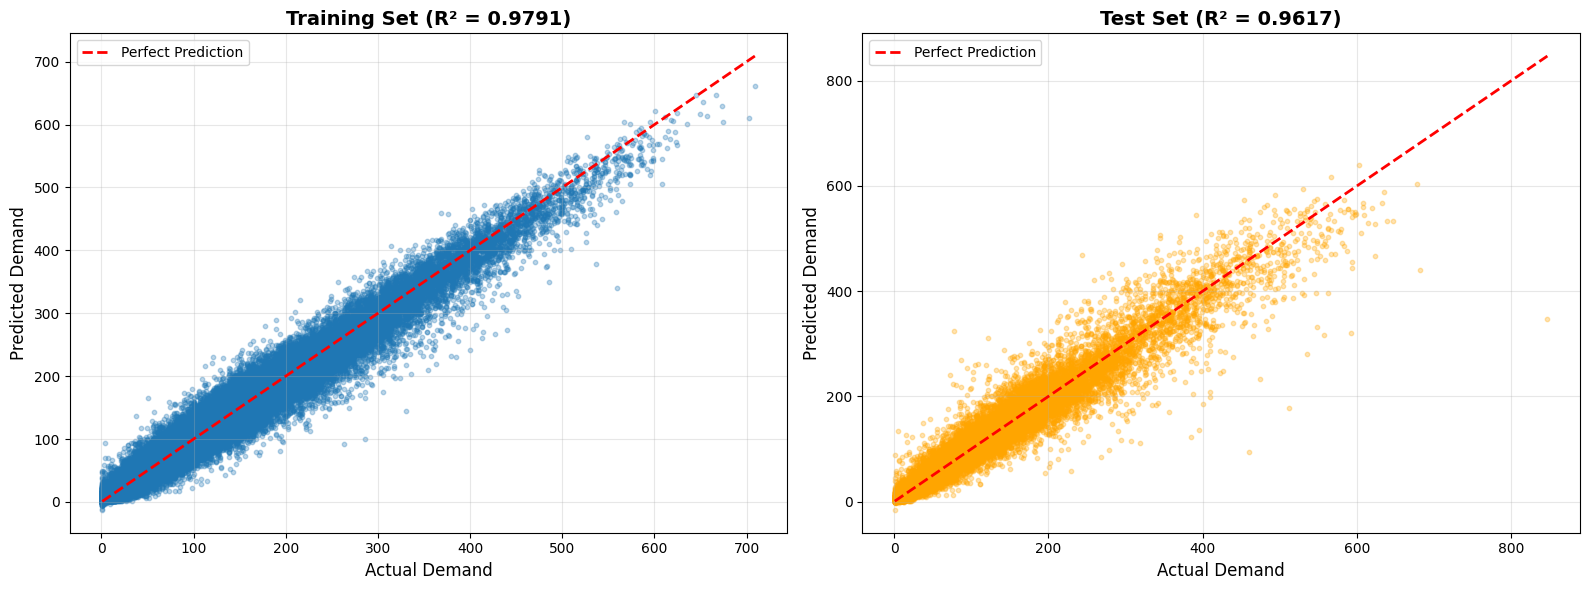

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_train, y_train_pred, alpha=0.3, s=10)
axes[0].plot([y_train.min(), y_train.max()], 
             [y_train.min(), y_train.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Demand', fontsize=12)
axes[0].set_ylabel('Predicted Demand', fontsize=12)
axes[0].set_title(f'Training Set (R² = {train_metrics["r2"]:.4f})', 
                  fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_test_pred, alpha=0.3, s=10, color='orange')
axes[1].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Demand', fontsize=12)
axes[1].set_ylabel('Predicted Demand', fontsize=12)
axes[1].set_title(f'Test Set (R² = {test_metrics["r2"]:.4f})', 
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/improved_predictions_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

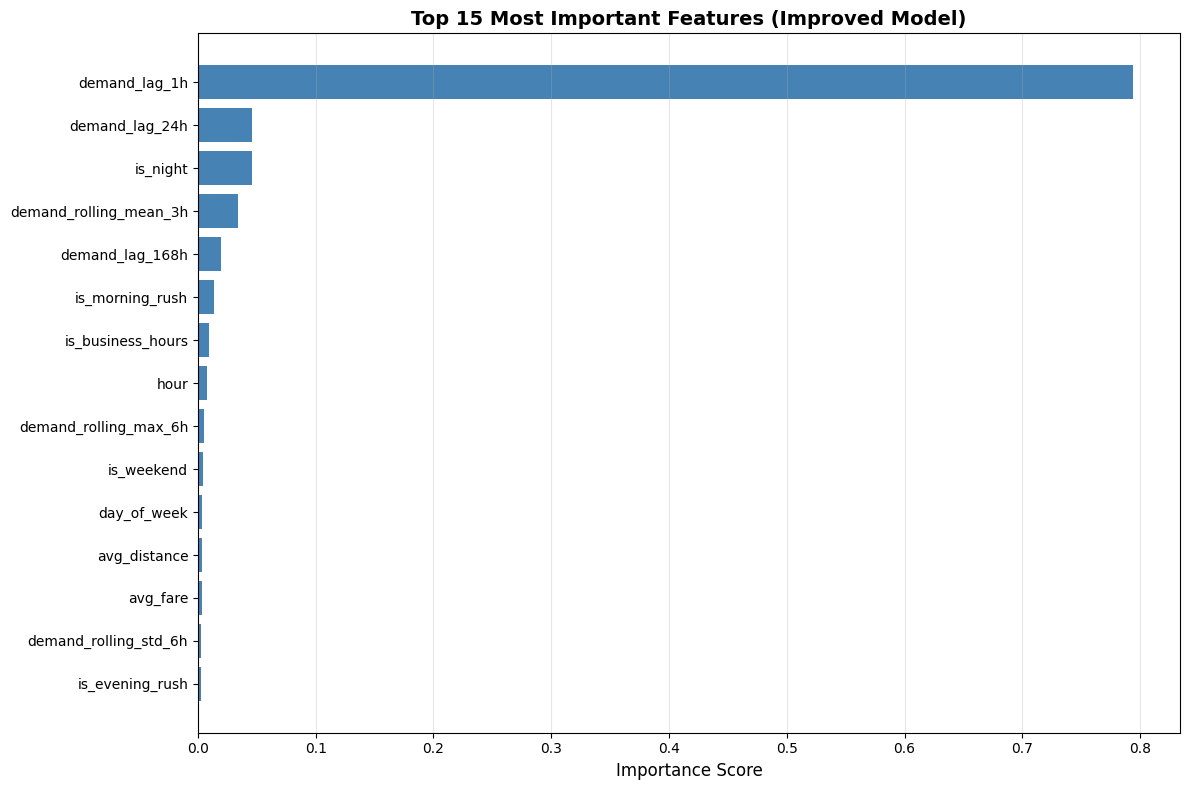


Top 10 Features:
  demand_lag_1h                  0.7942
  demand_lag_24h                 0.0462
  is_night                       0.0458
  demand_rolling_mean_3h         0.0343
  demand_lag_168h                0.0197
  is_morning_rush                0.0139
  is_business_hours              0.0093
  hour                           0.0075
  demand_rolling_max_6h          0.0055
  is_weekend                     0.0046


In [11]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='steelblue')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Most Important Features (Improved Model)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/improved_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Features:")
for idx, row in importance_df.head(10).iterrows():
    print(f"  {row['feature']:30s} {row['importance']:.4f}")

In [12]:
os.makedirs('../models', exist_ok=True)

# Save model
model.save_model('../models/xgboost_demand_model_improved.json')

with open('../models/xgboost_demand_model_improved.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save metadata
metadata = {
    'model_type': 'XGBoost Regressor (Improved)',
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'data_months': 6,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'features': feature_cols,
    'train_rmse': train_metrics['rmse'],
    'test_rmse': test_metrics['rmse'],
    'train_r2': train_metrics['r2'],
    'test_r2': test_metrics['r2'],
    'parameters': model.get_params()
}

import json
with open('../models/model_metadata_improved.json', 'w') as f:
    json.dump(metadata, f, indent=4, default=str)

print("\n" + "="*60)
print("IMPROVED MODEL SAVED!")
print("="*60)
print("✅ Model: models/xgboost_demand_model_improved.json")
print("✅ Model: models/xgboost_demand_model_improved.pkl")
print("✅ Metadata: models/model_metadata_improved.json")


IMPROVED MODEL SAVED!
✅ Model: models/xgboost_demand_model_improved.json
✅ Model: models/xgboost_demand_model_improved.pkl
✅ Metadata: models/model_metadata_improved.json


In [13]:
print("\n" + "="*60)
print("🎉 RETRAINING COMPLETE WITH MORE DATA! 🎉")
print("="*60)
print(f"Data Used: {len(dfs)} months ({len(df):,} total trips)")
print(f"Training Samples: {len(X_train):,}")
print(f"Test Samples: {len(X_test):,}")
print(f"\nFinal Performance:")
print(f"  Test R²:   {test_metrics['r2']:.4f}")
print(f"  Test RMSE: {test_metrics['rmse']:.2f} trips")
print(f"  Test MAE:  {test_metrics['mae']:.2f} trips")
print("="*60)
print("\n✅ Your improved model is ready to use!")
print("💡 Use this model in notebook 04 for better predictions!")


🎉 RETRAINING COMPLETE WITH MORE DATA! 🎉
Data Used: 6 months (24,657,172 total trips)
Training Samples: 379,426
Test Samples: 94,857

Final Performance:
  Test R²:   0.9617
  Test RMSE: 13.58 trips
  Test MAE:  5.65 trips

✅ Your improved model is ready to use!
💡 Use this model in notebook 04 for better predictions!
